# PREPROCESS 

In [15]:
!pip install librosa numpy matplotlib soundfile scikit-learn imbalanced-learn tqdm
!mkdir visuals

A subdirectory or file visuals already exists.


### STEP 1: DATA PREPROCESSING & CLEANING WITH PLOTS

🔁 Preprocessing and visualizing...


belly pain:  25%|██▍       | 36/145 [00:00<00:02, 43.34it/s]

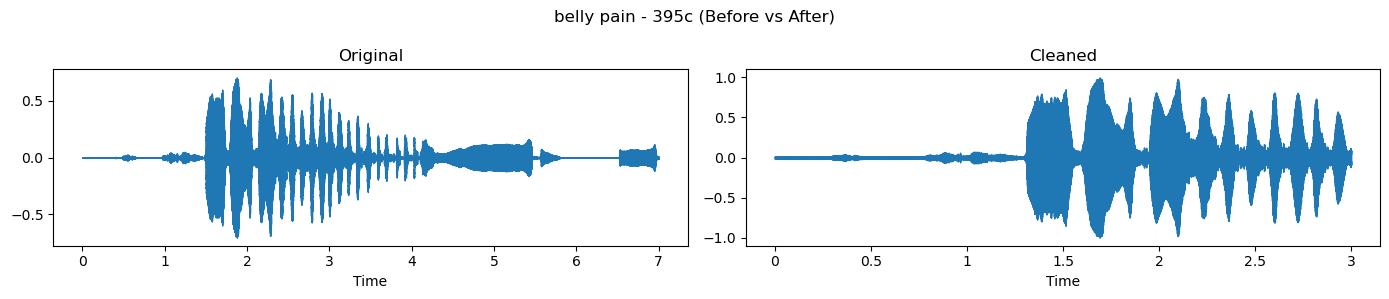

belly pain:  31%|███       | 45/145 [00:02<00:10,  9.88it/s]

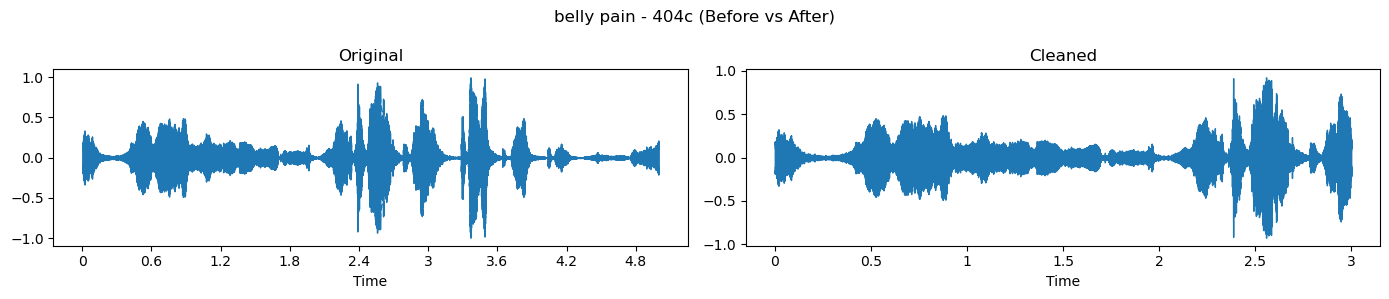

belly pain:  67%|██████▋   | 97/145 [00:05<00:01, 34.36it/s]

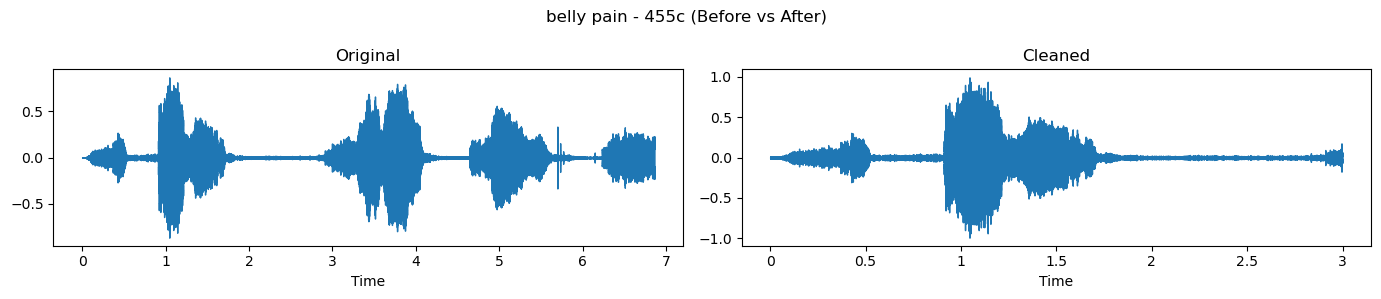

belly pain:  70%|███████   | 102/145 [00:07<00:04,  9.48it/s]

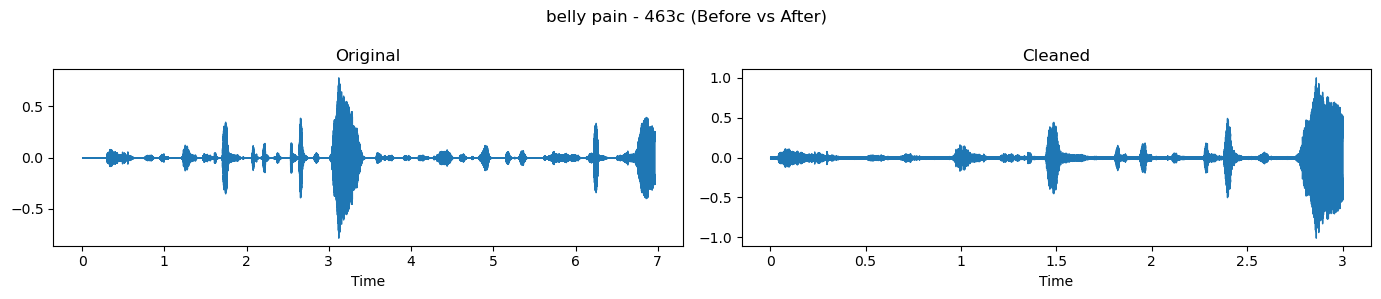

belly pain:  89%|████████▉ | 129/145 [00:09<00:00, 18.64it/s]

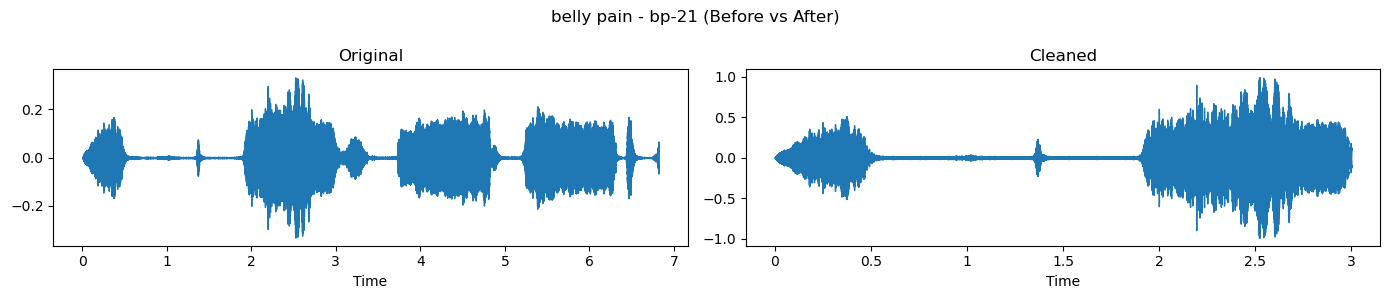

burping:   0%|          | 0/133 [00:00<?, ?it/s]

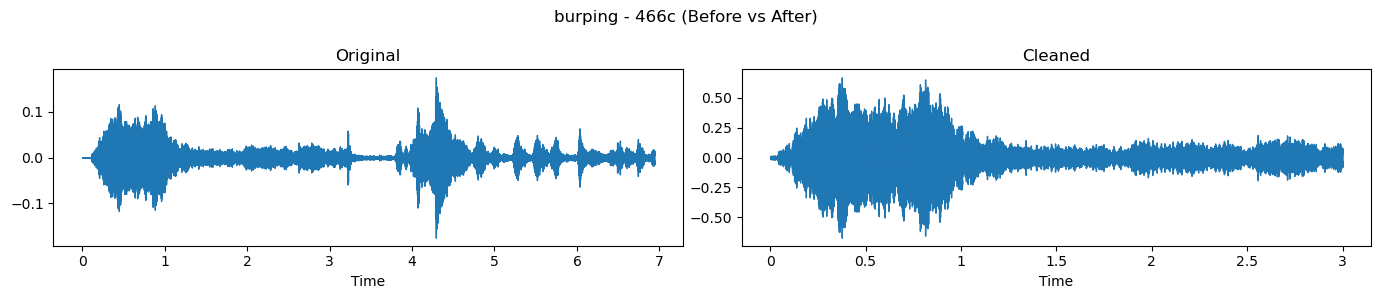

burping:   2%|▏         | 3/133 [00:01<01:25,  1.52it/s]

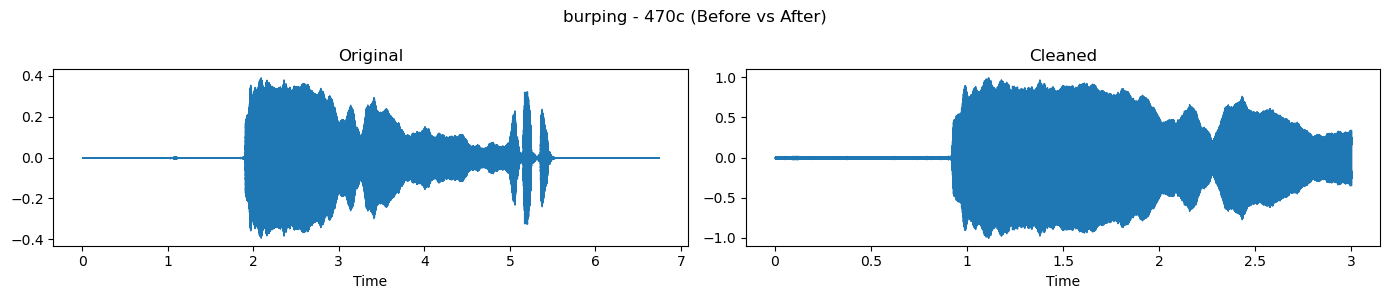

burping:   5%|▌         | 7/133 [00:04<01:12,  1.75it/s]

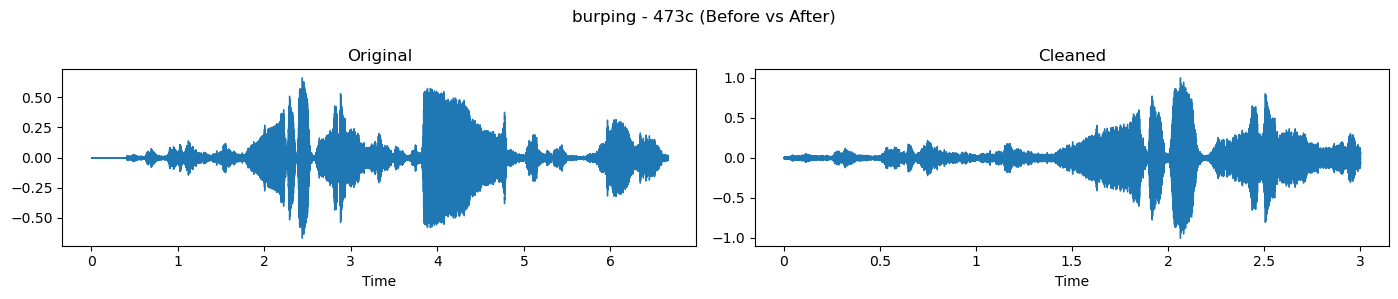

burping:  46%|████▌     | 61/133 [00:07<00:02, 32.17it/s]

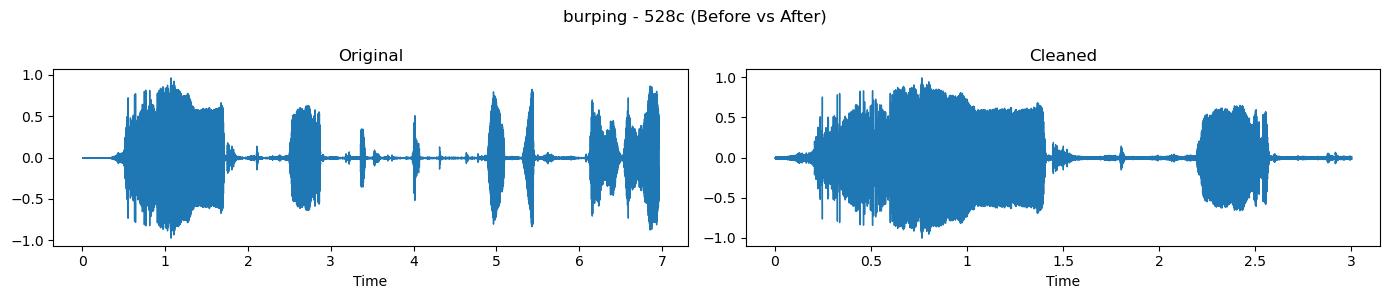

burping:  80%|███████▉  | 106/133 [00:10<00:00, 35.05it/s]

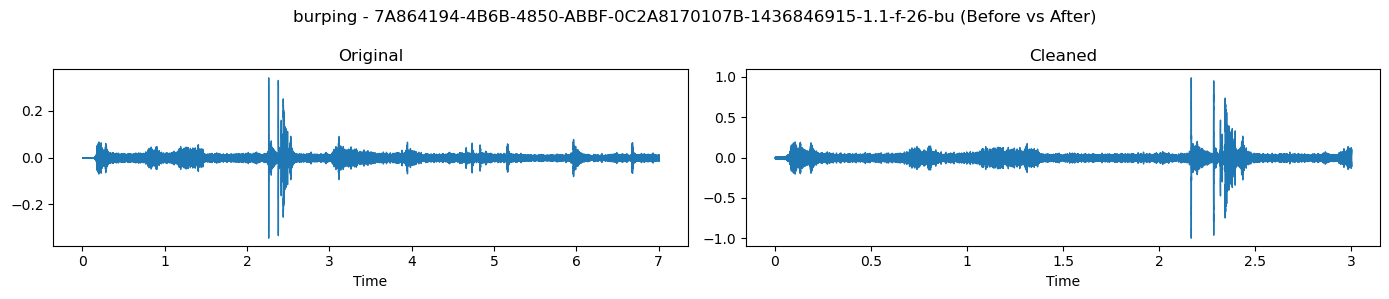

burping:  93%|█████████▎| 124/133 [00:11<00:00, 18.20it/s]

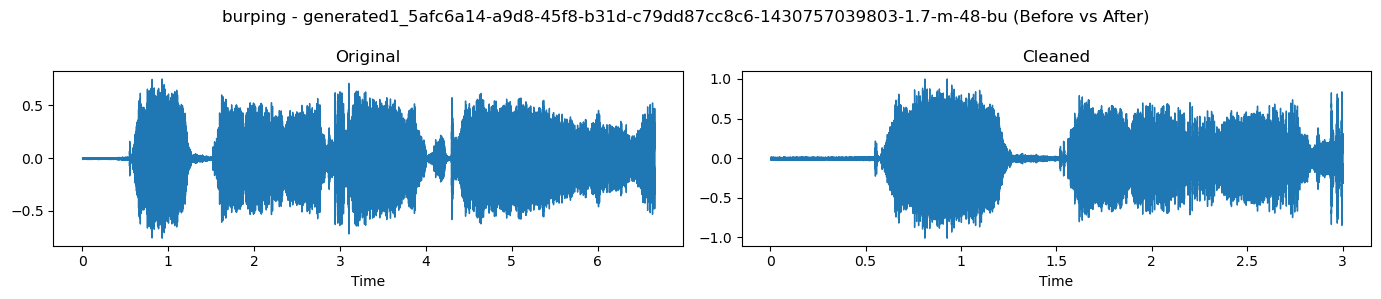

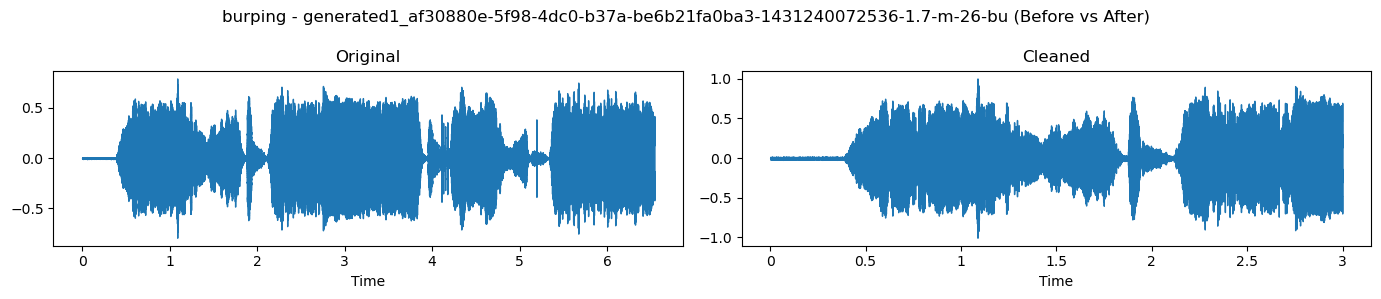

burping:  97%|█████████▋| 129/133 [00:16<00:01,  3.61it/s]

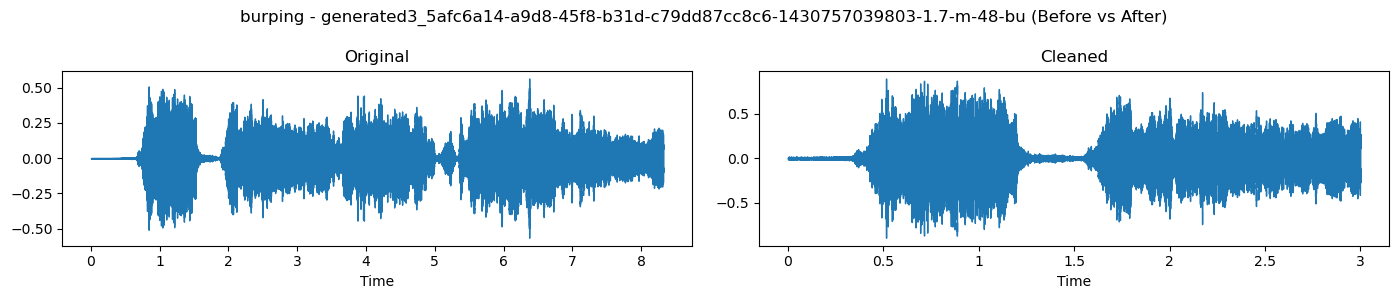

discomfort:   4%|▍         | 6/160 [00:00<00:05, 30.51it/s]

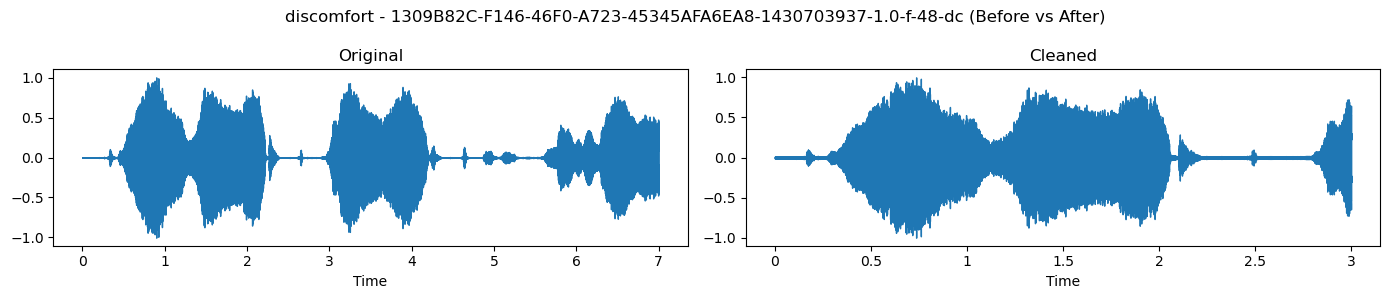

discomfort:  38%|███▊      | 60/160 [00:03<00:02, 35.31it/s]

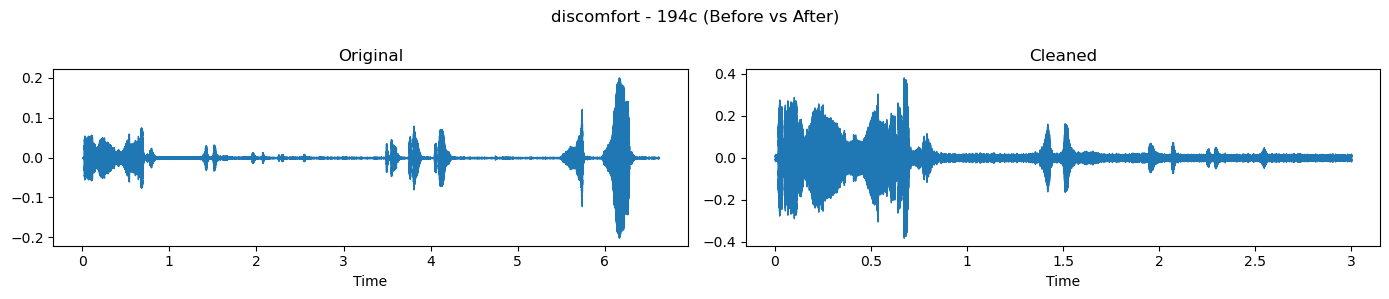

discomfort:  43%|████▎     | 69/160 [00:05<00:09,  9.21it/s]

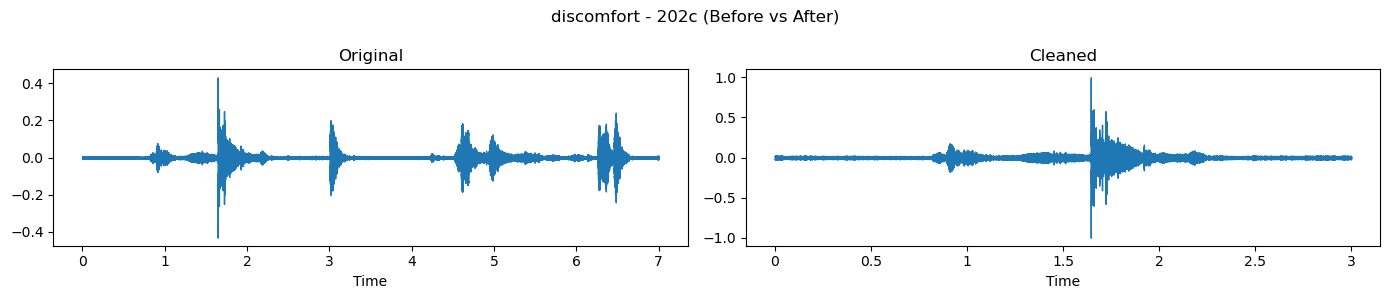

discomfort:  53%|█████▎    | 85/160 [00:07<00:06, 11.04it/s]

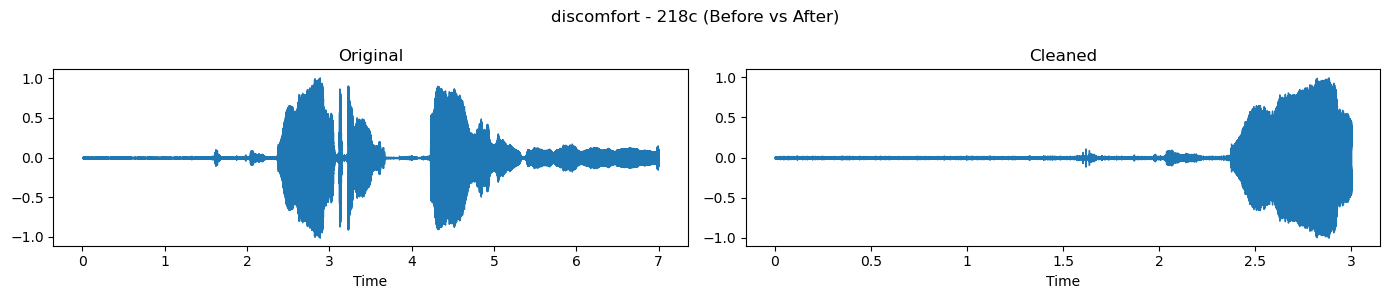

discomfort:  84%|████████▍ | 135/160 [00:09<00:00, 32.54it/s]

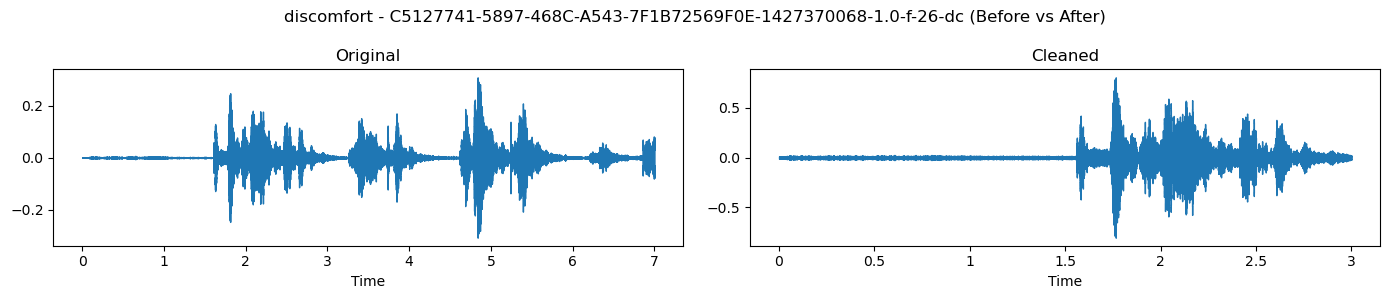

discomfort:  90%|█████████ | 144/160 [00:12<00:01,  9.20it/s]

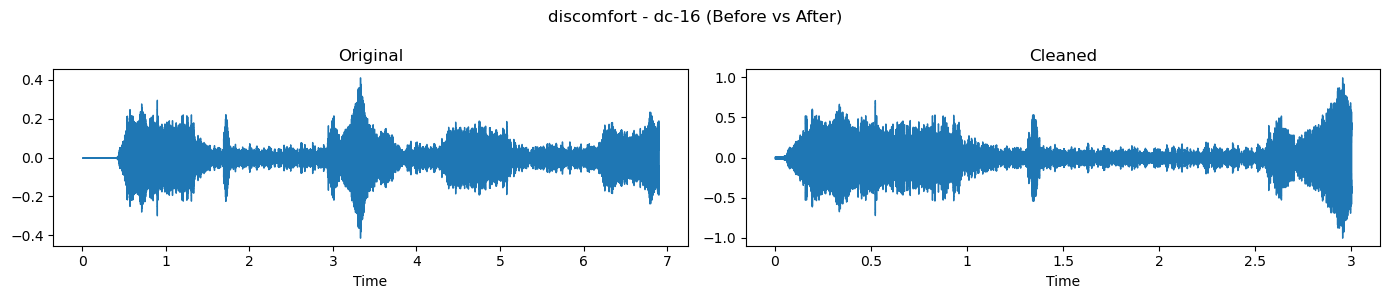

discomfort:  97%|█████████▋| 155/160 [00:14<00:00,  8.02it/s]

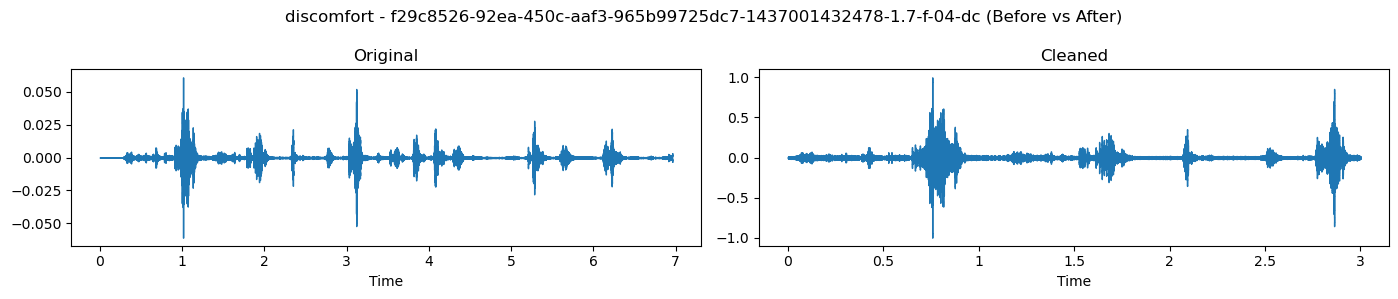

hungry:   4%|▎         | 14/397 [00:00<00:10, 36.76it/s]

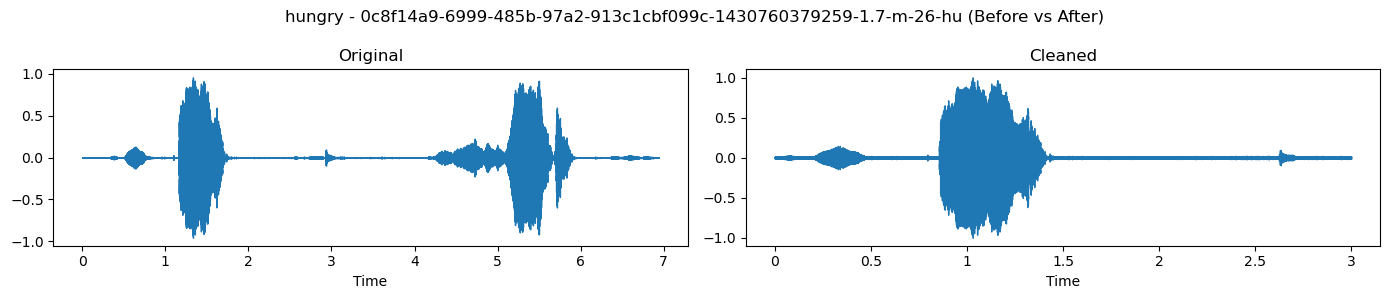

hungry:   6%|▌         | 22/397 [00:02<00:51,  7.28it/s]

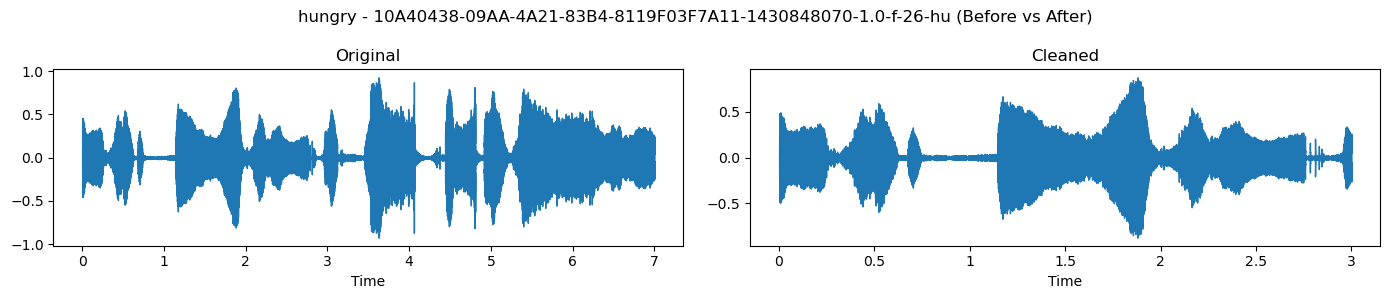

hungry:   7%|▋         | 29/397 [00:04<01:15,  4.89it/s]

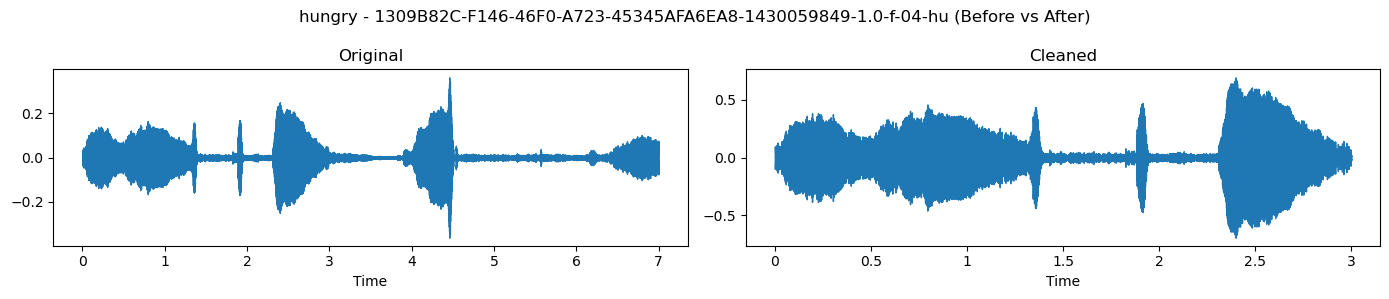

hungry:  11%|█         | 44/397 [00:07<00:42,  8.37it/s]

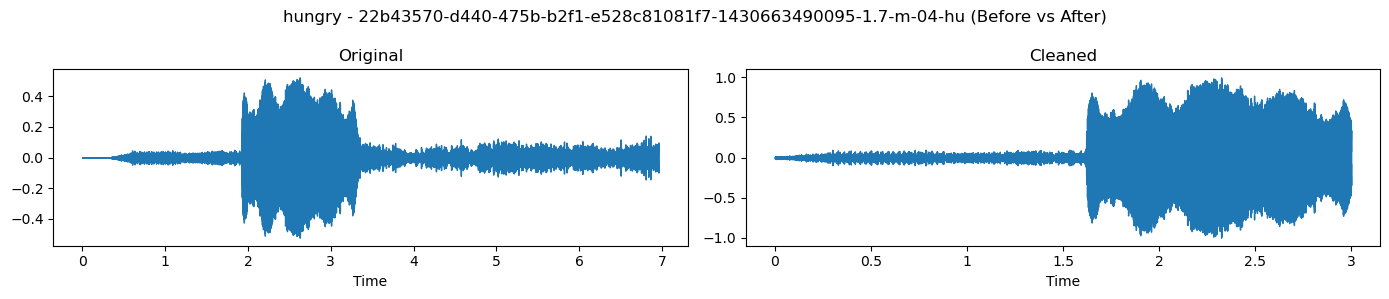

hungry:  31%|███       | 123/397 [00:10<00:07, 35.31it/s]

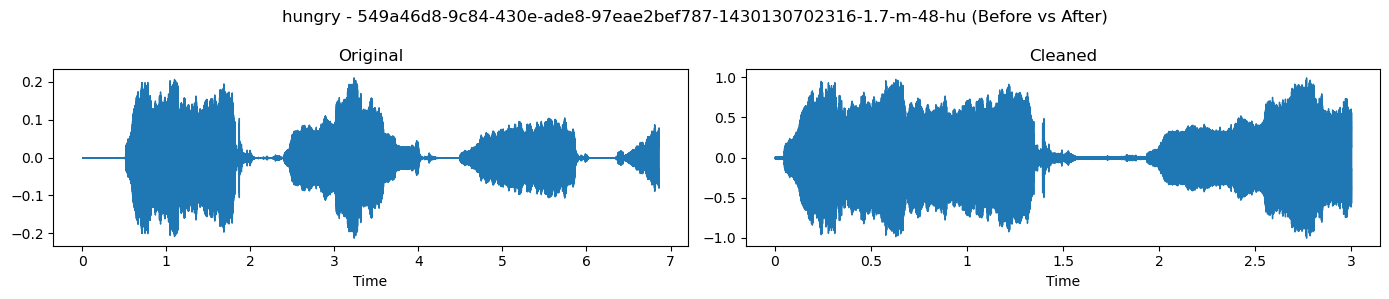

hungry:  33%|███▎      | 131/397 [00:12<00:33,  7.92it/s]

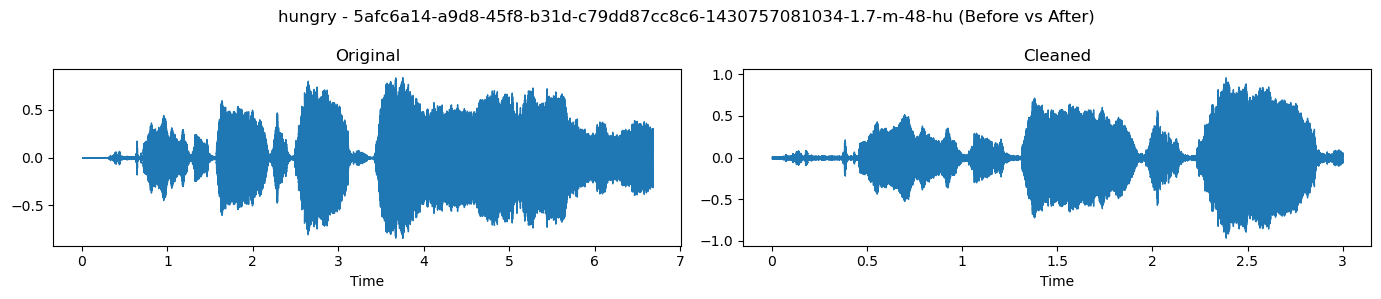

hungry:  36%|███▌      | 143/397 [00:15<00:35,  7.10it/s]

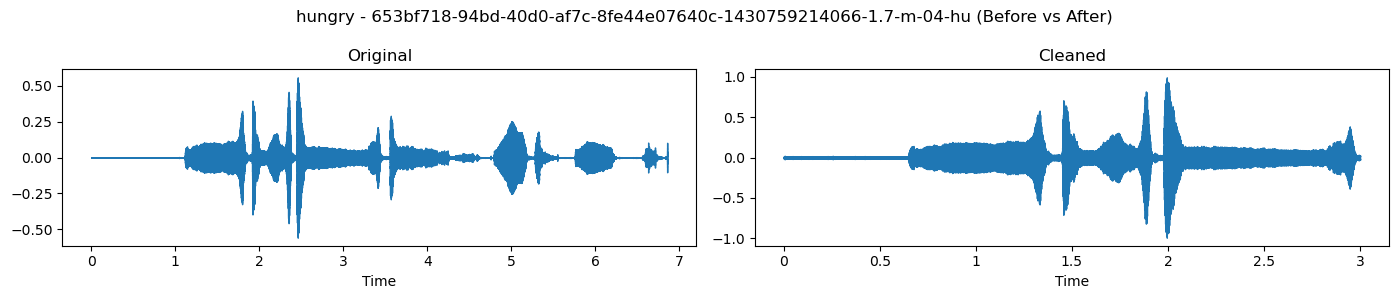

hungry:  42%|████▏     | 168/397 [00:17<00:14, 16.07it/s]

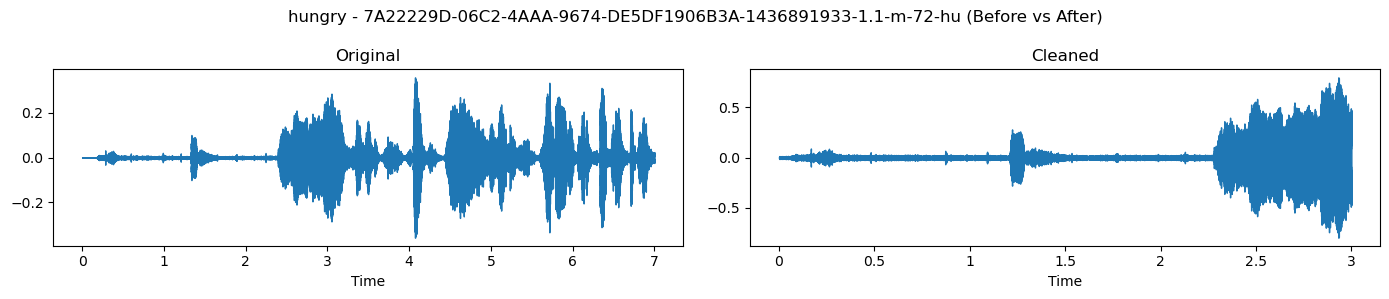

hungry:  45%|████▌     | 180/397 [00:19<00:23,  9.16it/s]

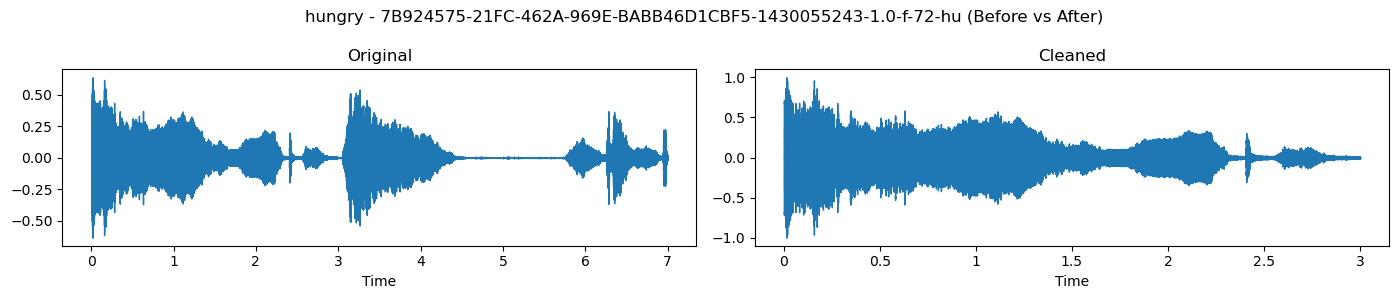

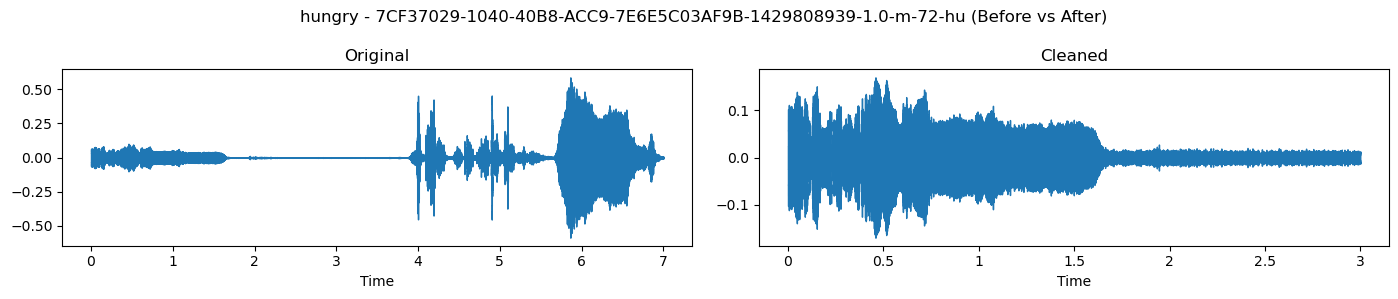

hungry:  48%|████▊     | 189/397 [00:23<00:50,  4.11it/s]

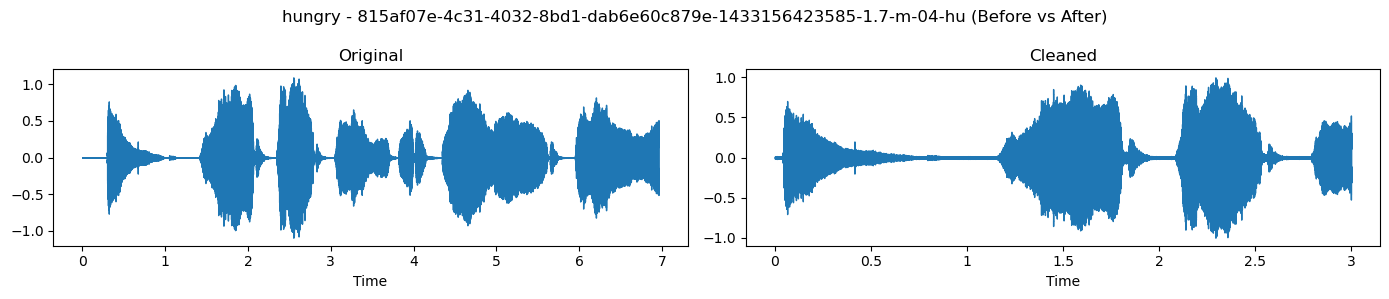

hungry:  49%|████▉     | 194/397 [00:25<00:51,  3.91it/s]

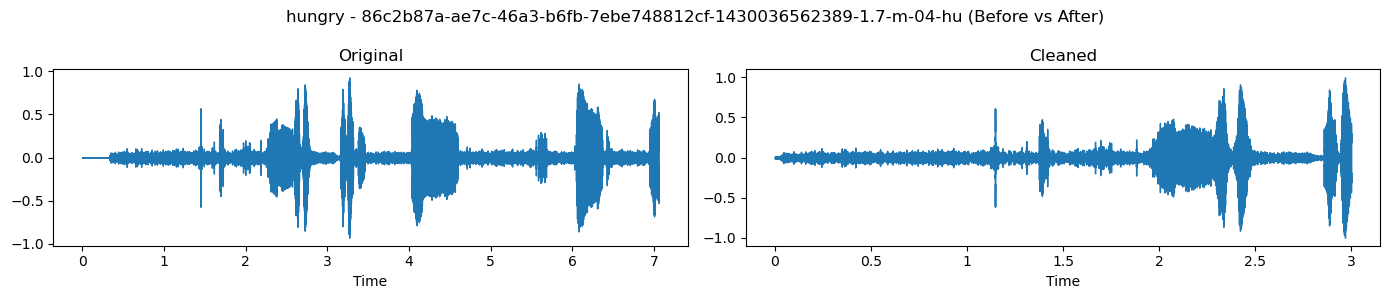

hungry:  54%|█████▍    | 214/397 [00:27<00:18,  9.82it/s]

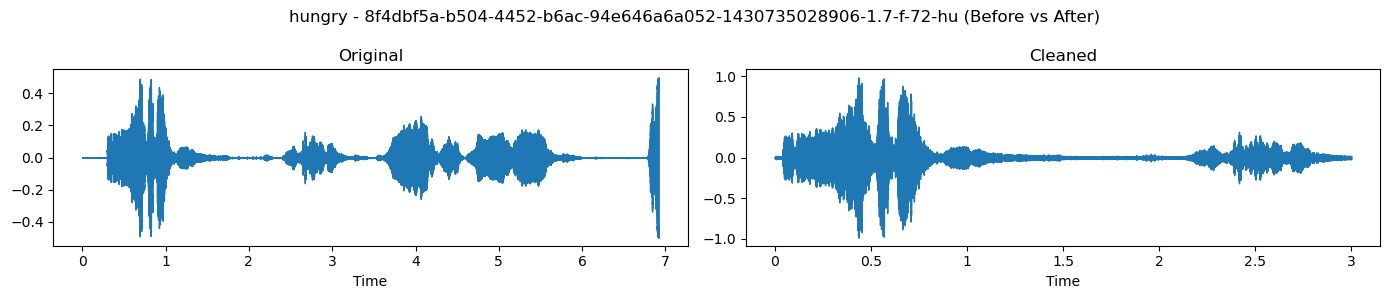

hungry:  59%|█████▊    | 233/397 [00:29<00:12, 13.46it/s]

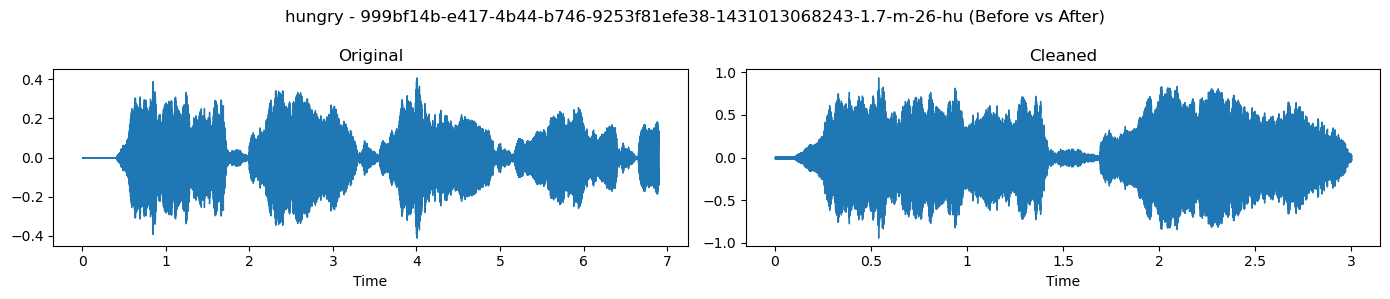

hungry:  60%|█████▉    | 237/397 [00:31<00:36,  4.40it/s]

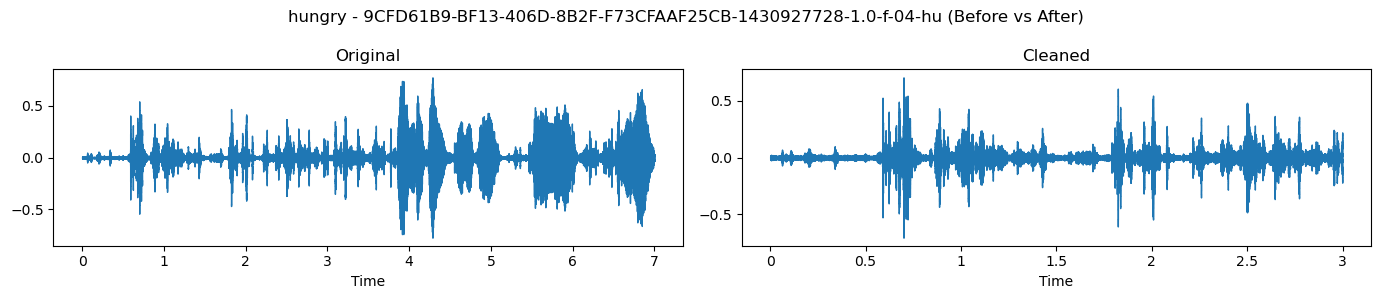

hungry:  63%|██████▎   | 252/397 [00:34<00:18,  7.97it/s]

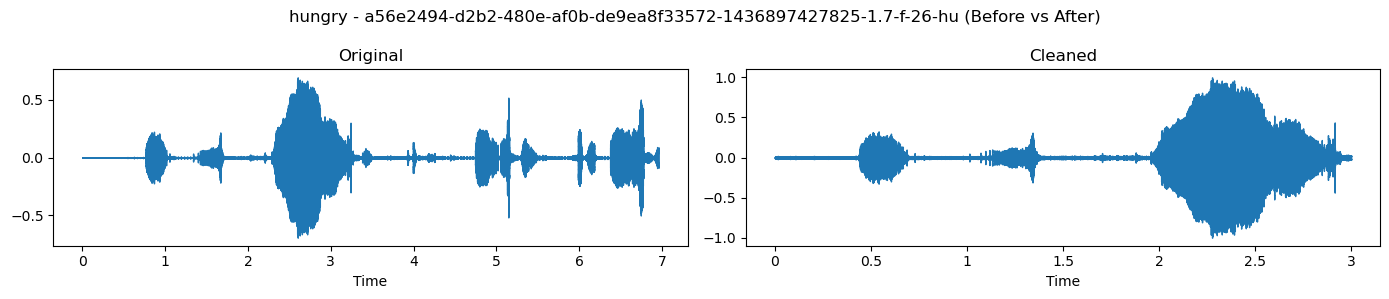

hungry:  67%|██████▋   | 267/397 [00:36<00:13,  9.86it/s]

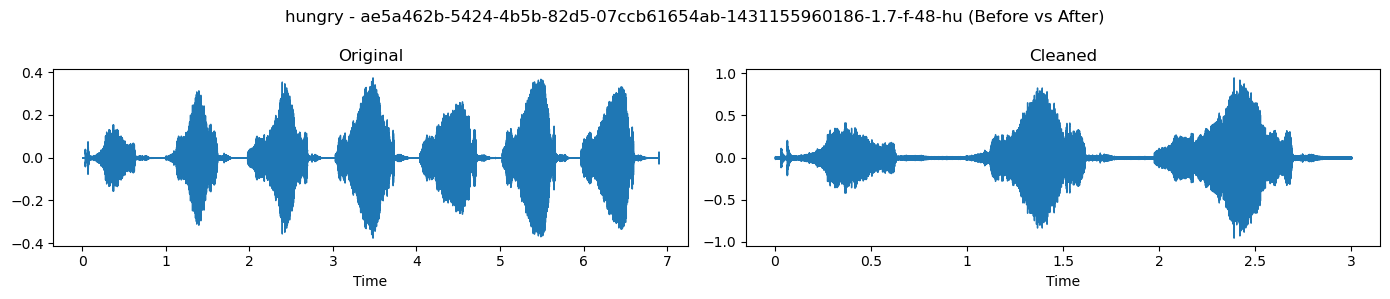

hungry:  70%|██████▉   | 276/397 [00:40<00:30,  4.02it/s]

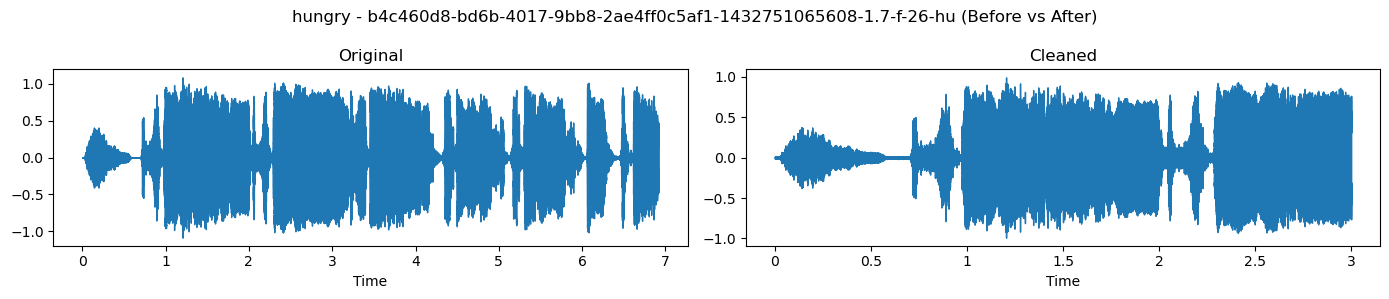

hungry:  72%|███████▏  | 285/397 [00:42<00:24,  4.51it/s]

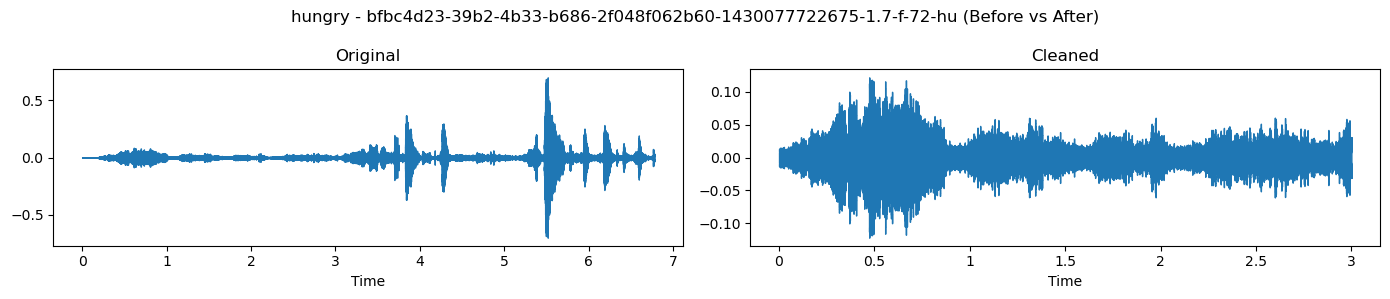

hungry:  78%|███████▊  | 310/397 [00:45<00:06, 14.07it/s]

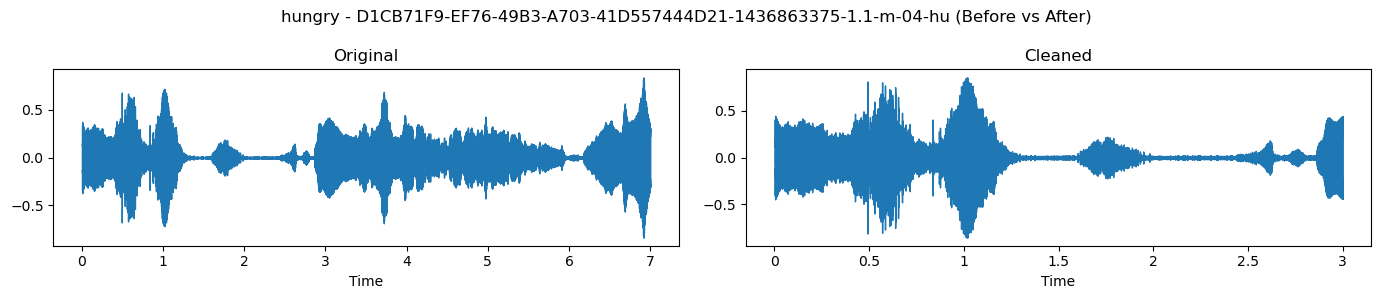

hungry:  91%|█████████ | 360/397 [00:48<00:01, 31.75it/s]

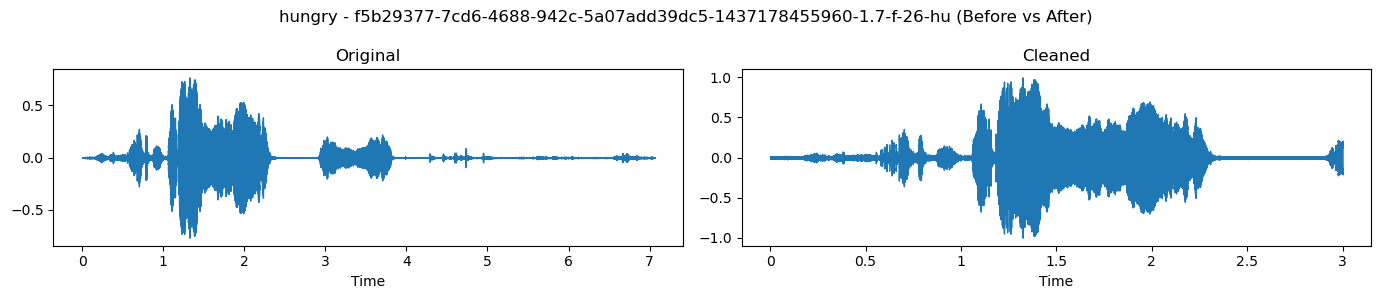

tired:   3%|▎         | 5/173 [00:00<00:04, 39.36it/s]

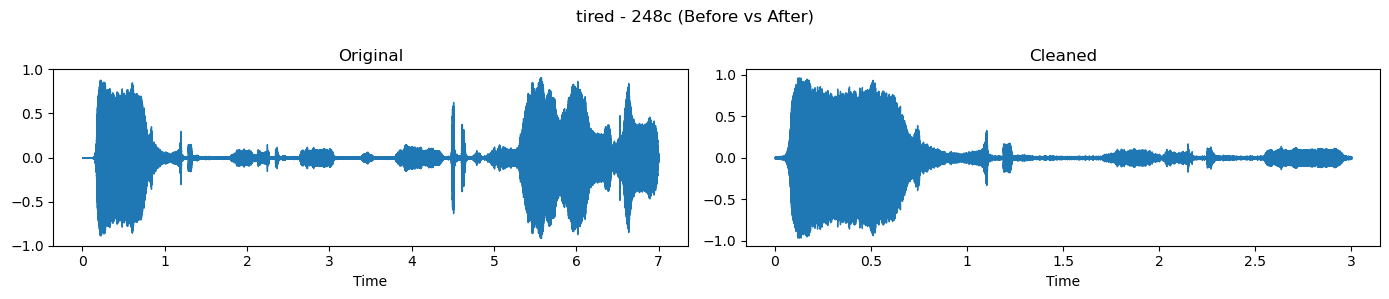

tired:  14%|█▍        | 25/173 [00:02<00:09, 15.53it/s]

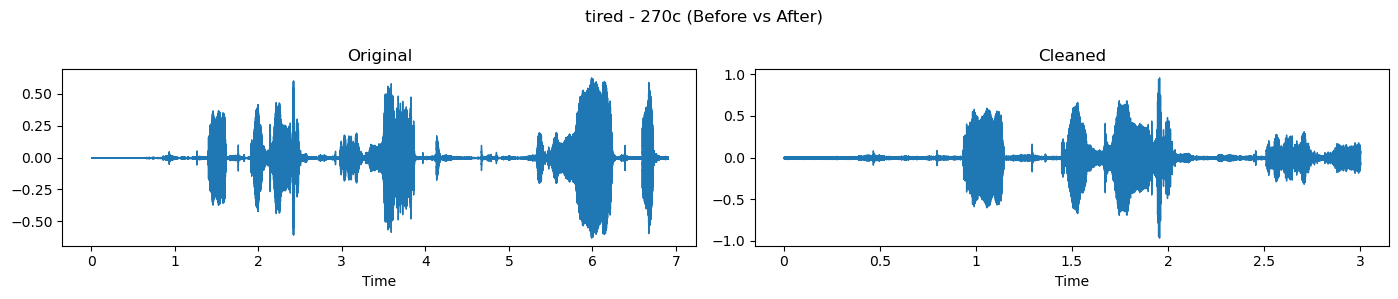

tired:  17%|█▋        | 29/173 [00:04<00:29,  4.83it/s]

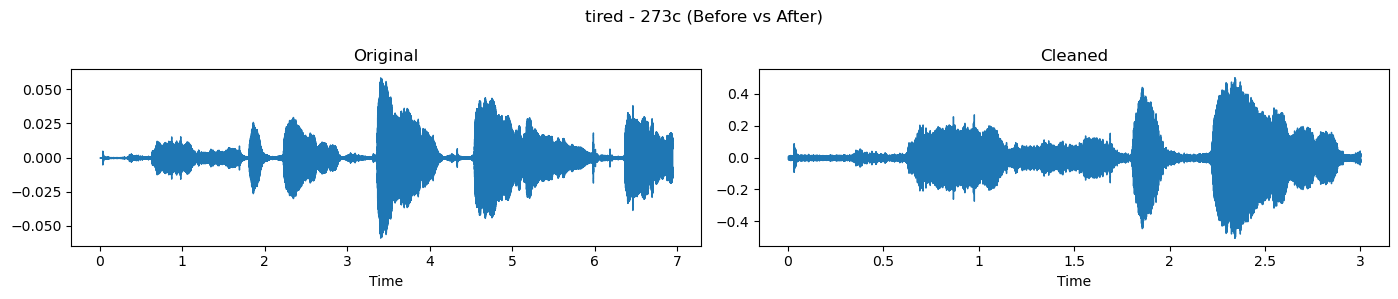

tired:  46%|████▌     | 79/173 [00:07<00:03, 27.58it/s]

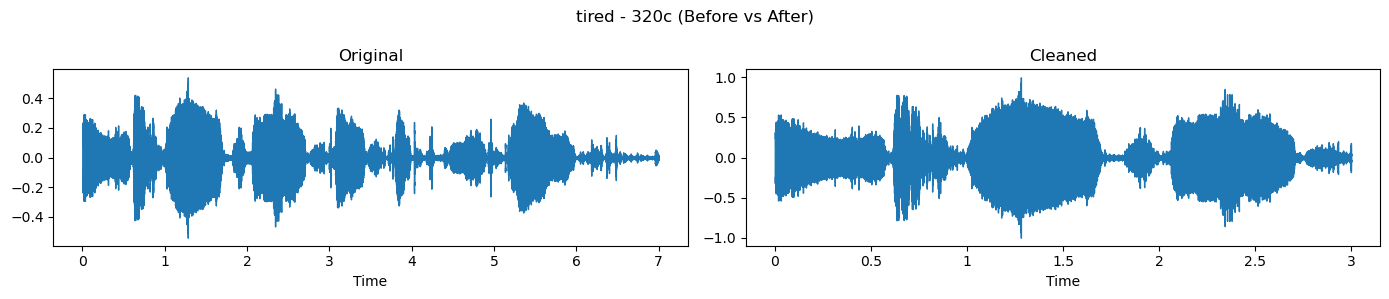

tired:  53%|█████▎    | 92/173 [00:09<00:07, 10.26it/s]

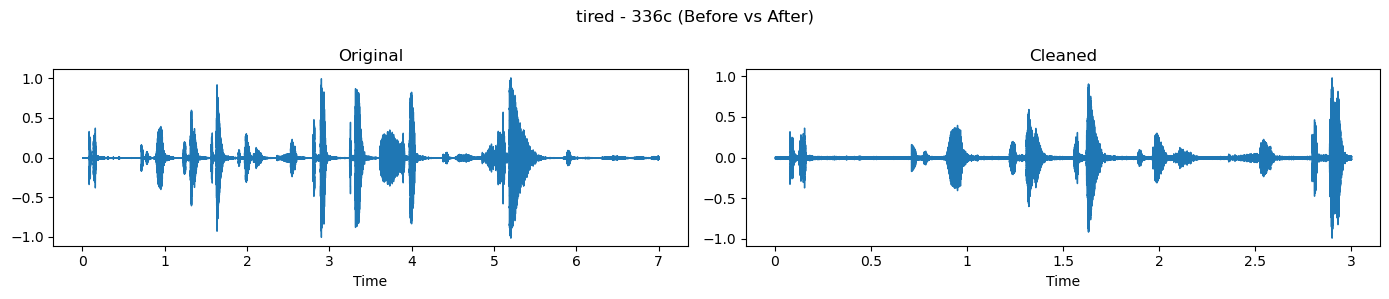

tired:  65%|██████▌   | 113/173 [00:11<00:04, 14.76it/s]

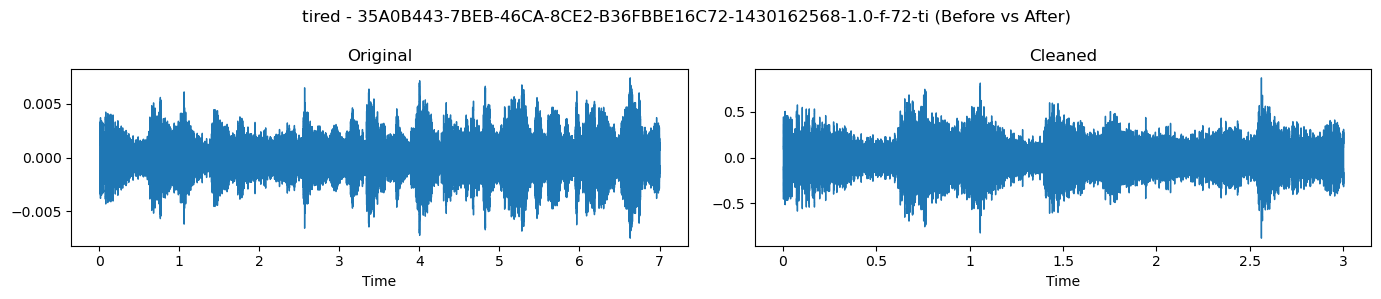

tired:  68%|██████▊   | 117/173 [00:13<00:10,  5.10it/s]

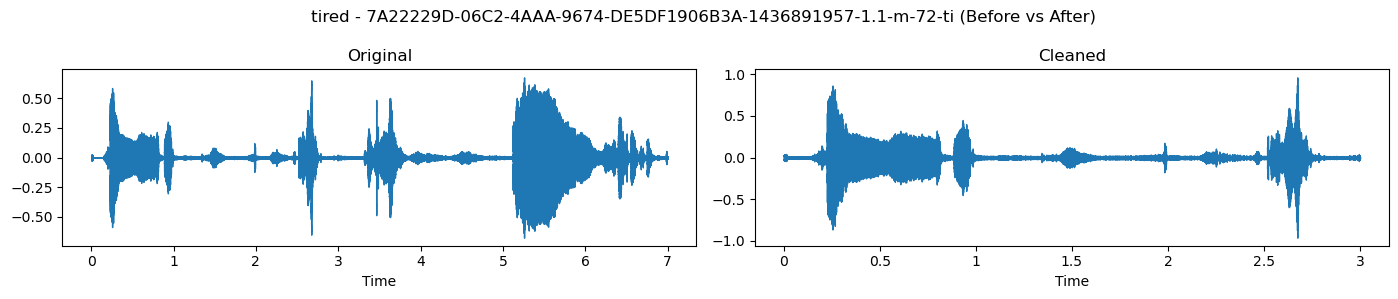

tired:  88%|████████▊ | 152/173 [00:16<00:00, 24.87it/s]C:\Users\user\AppData\Local\Temp\ipykernel_23840\1384997828.py:27: RuntimeWarning: invalid value encountered in divide
  signal = signal / np.max(np.abs(signal))  # Normalize
tired:  95%|█████████▌| 165/173 [00:16<00:00, 37.71it/s]

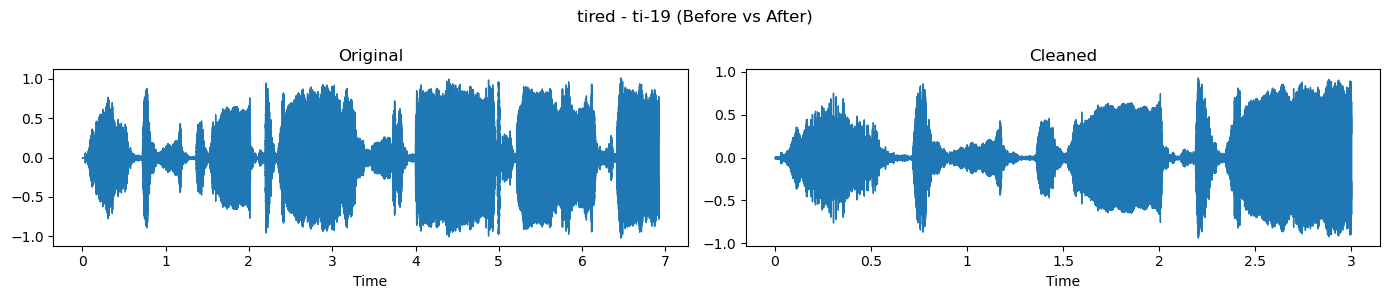

tired: 100%|██████████| 173/173 [00:19<00:00,  9.08it/s]


📊 Applying SMOTE balancing...
✅ Done! Waveforms saved in /visuals. Clean data saved as X_clean.npy & y_clean.npy


In [17]:
import os
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import librosa.display
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from tqdm import tqdm
import random

# === Step A: Settings ===
SAMPLE_RATE = 22050
MAX_DURATION = 3
MAX_LENGTH = SAMPLE_RATE * MAX_DURATION

# ✅ Make sure these folders exist!
TARGET_CLASSES = ['belly pain', 'burping', 'discomfort', 'hungry', 'tired']
data_dir = r'C:\Users\user\Desktop\NEW DATASET'

X = []
y = []

# === Step B: Preprocessing Function ===
def clean_audio(file_path):
    signal, _ = librosa.load(file_path, sr=SAMPLE_RATE)
    signal = signal / np.max(np.abs(signal))  # Normalize
    signal, _ = librosa.effects.trim(signal)  # Silence removal
    signal += np.random.normal(0, 0.005, len(signal))  # Noise injection

    if len(signal) > MAX_LENGTH:
        signal = signal[:MAX_LENGTH]
    else:
        signal = np.pad(signal, (0, MAX_LENGTH - len(signal)))
    
    return signal

# === Step C: Visualize and Save Waveforms ===
def save_waveform_comparison(original, cleaned, label, filename):
    fig, axs = plt.subplots(1, 2, figsize=(14, 3))
    fig.suptitle(f"{label} - {filename} (Before vs After)")

    axs[0].set_title("Original")
    librosa.display.waveshow(original, sr=SAMPLE_RATE, ax=axs[0])

    axs[1].set_title("Cleaned")
    librosa.display.waveshow(cleaned, sr=SAMPLE_RATE, ax=axs[1])

    plt.tight_layout()
    plt.show()
    plt.savefig(f"visuals/waveform_COMPARE_{label}_{filename}.png")
    plt.close()

# === Step D: Process All Files ===
print("🔁 Preprocessing and visualizing...")

for label in TARGET_CLASSES:
    class_path = os.path.join(data_dir, label)
    if not os.path.exists(class_path):
        print(f"❌ Folder not found: {class_path}")
        continue

    for file in tqdm(os.listdir(class_path), desc=label):
        if not file.endswith('.wav'):
            continue

        file_path = os.path.join(class_path, file)
        try:
            # Load original
            original, _ = librosa.load(file_path, sr=SAMPLE_RATE)

            # Cleaned version
            cleaned = clean_audio(file_path)

            # Save waveform comparison (only some files)
            if random.random() < 0.05:
                save_waveform_comparison(original, cleaned, label, file.replace('.wav', ''))
                sf.write(f"visuals/cleaned_{label}_{file}", cleaned, SAMPLE_RATE)

            # Store for SMOTE & training
            X.append(cleaned)
            y.append(label)

        except Exception as e:
            print(f"❌ Error with {file}: {e}")

# === Step E: Apply SMOTE ===
print("📊 Applying SMOTE balancing...")
X_np = np.array(X)
X_flat = X_np.reshape((X_np.shape[0], -1))
y_encoded = LabelEncoder().fit_transform(y)

X_smote, y_smote = RandomOverSampler().fit_resample(X_flat, y_encoded)
X_balanced = X_smote.reshape((-1, MAX_LENGTH))

np.save('X_clean.npy', X_balanced)
np.save('y_clean.npy', y_smote)

print("✅ Done! Waveforms saved in /visuals. Clean data saved as X_clean.npy & y_clean.npy")


### STEP 2: FEATURE EXTRACTION (MFCC + MEL + PLOTS)

🎧 Extracting features and generating plots...


  0%|          | 0/1985 [00:00<?, ?it/s]

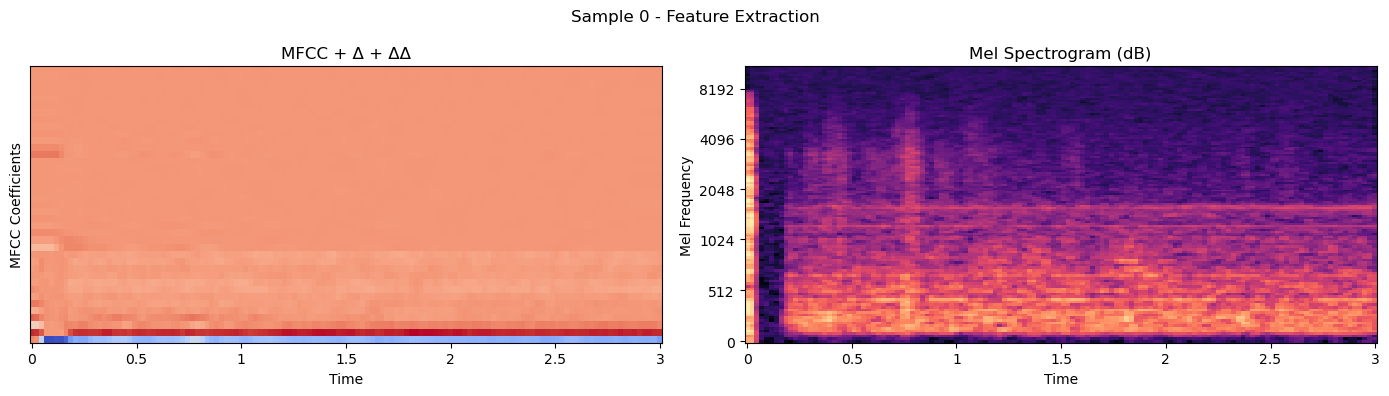

  0%|          | 1/1985 [00:01<34:11,  1.03s/it]

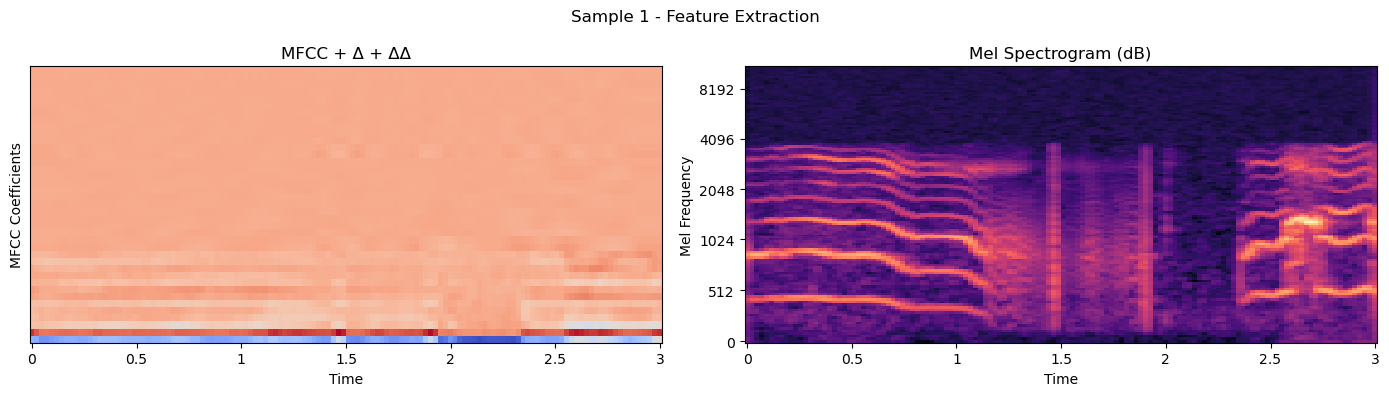

  0%|          | 2/1985 [00:02<34:38,  1.05s/it]

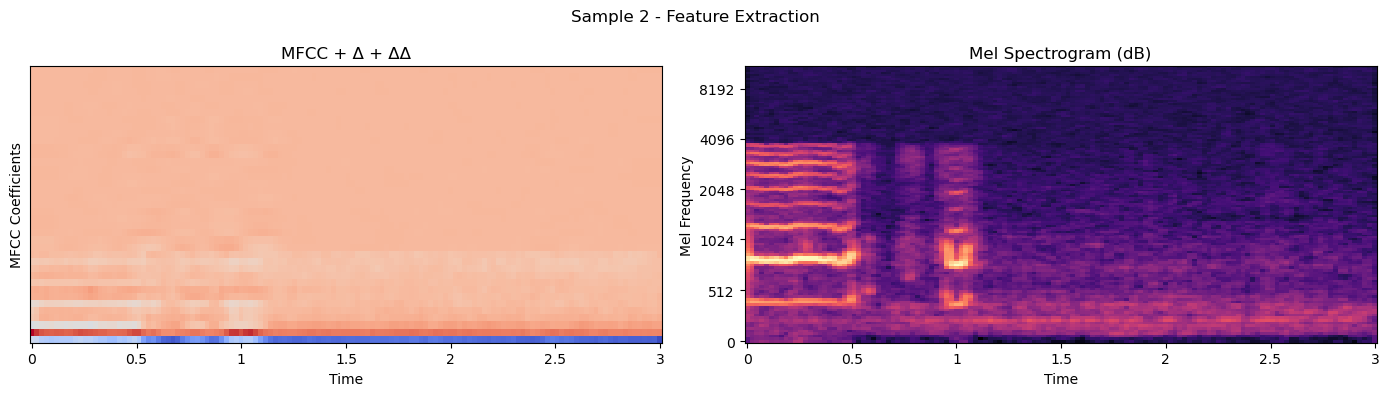

  0%|          | 3/1985 [00:03<35:16,  1.07s/it]

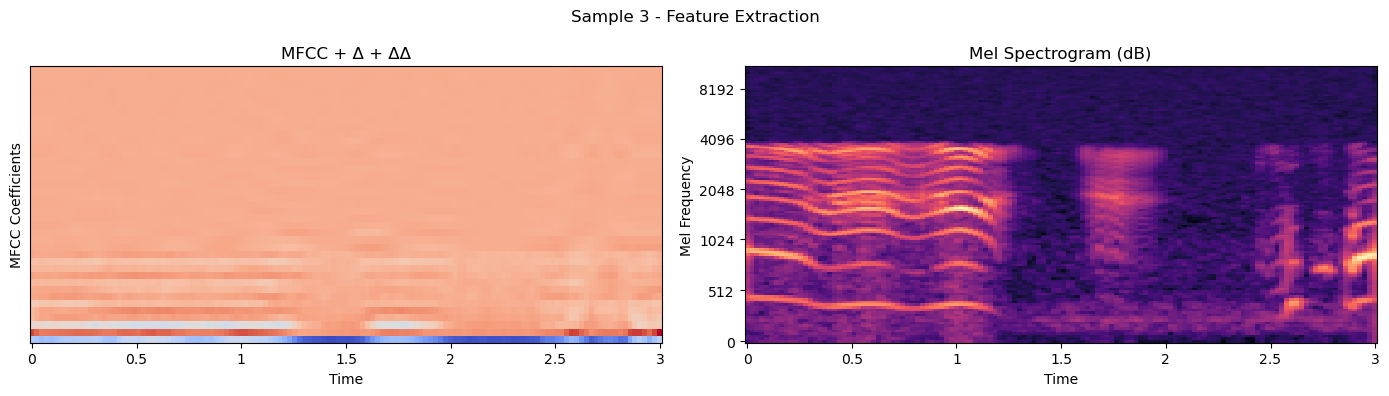

  0%|          | 4/1985 [00:04<35:45,  1.08s/it]

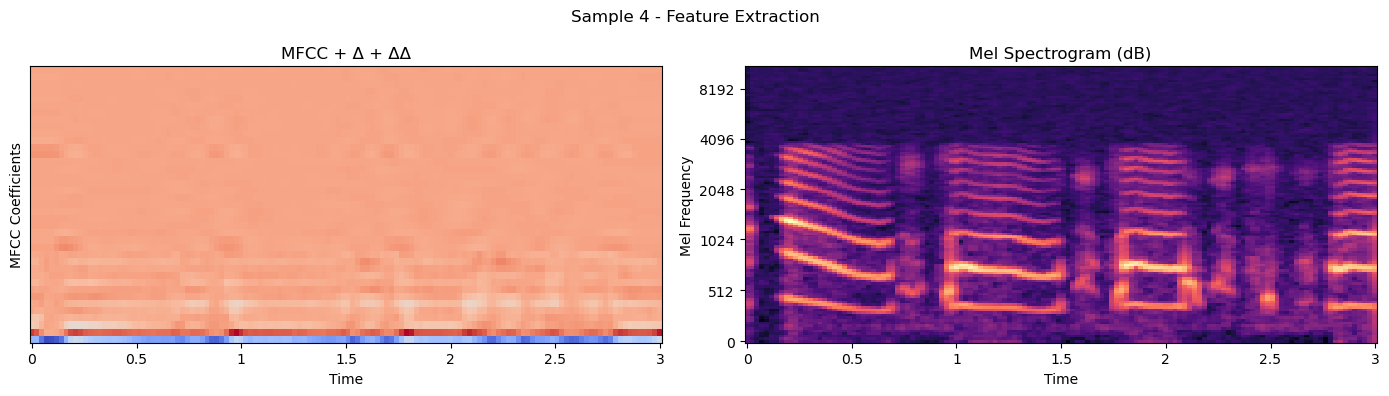

100%|██████████| 1985/1985 [01:37<00:00, 20.37it/s]


✅ Feature extraction complete!
📁 Saved feature plots: visuals/feature_plot_0.png ... feature_plot_4.png
💾 Saved features as: X_final.npy


In [21]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

# === Step A: Load cleaned audio ===
SAMPLE_RATE = 22050
X_clean = np.load('X_clean.npy')
y_clean = np.load('y_clean.npy')

# === Step B: Create visuals folder if not exists ===
os.makedirs("visuals", exist_ok=True)

# === Step C: Define feature extraction ===
def extract_features(signal):
    # MFCC + delta + delta-delta
    mfcc = librosa.feature.mfcc(y=signal, sr=SAMPLE_RATE, n_mfcc=13)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    mfcc_combined = np.vstack([mfcc, delta, delta2])  # (39, T)

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=signal, sr=SAMPLE_RATE)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Crop both to same length
    min_T = min(mfcc_combined.shape[1], mel_db.shape[1])
    mfcc_cropped = mfcc_combined[:, :min_T]
    mel_cropped = mel_db[:, :min_T]

    # Final feature: stacked vertically
    combined = np.vstack([mfcc_cropped, mel_cropped])  # shape: (39 + mel_bins, T)
    return combined, mfcc_cropped, mel_cropped

# === Step D: Loop through all cleaned audio ===
X_feat = []
print("🎧 Extracting features and generating plots...")

for i in tqdm(range(len(X_clean))):
    signal = X_clean[i]
    combined, mfcc_only, mel_only = extract_features(signal)
    X_feat.append(combined)

    if i < 5:  # only plot first 5
        fig, axs = plt.subplots(1, 2, figsize=(14, 4))
        fig.suptitle(f"Sample {i} - Feature Extraction")

        axs[0].set_title("MFCC + Δ + ΔΔ")
        librosa.display.specshow(mfcc_only, sr=SAMPLE_RATE, x_axis='time', ax=axs[0])
        axs[0].set_ylabel("MFCC Coefficients")

        axs[1].set_title("Mel Spectrogram (dB)")
        librosa.display.specshow(mel_only, sr=SAMPLE_RATE, x_axis='time', y_axis='mel', ax=axs[1])
        axs[1].set_ylabel("Mel Frequency")

        plt.tight_layout()
        plt.savefig(f"visuals/feature_plot_{i}.png")
        plt.show()  # show in Jupyter
        plt.close()

# === Step E: Pad time dimension ===
max_len = max(f.shape[1] for f in X_feat)
X_padded = [np.pad(f, ((0, 0), (0, max_len - f.shape[1])), mode='constant') for f in X_feat]
X_final = np.array(X_padded)

# === Step F: Save final features and labels ===
np.save("X_final.npy", X_final)
np.save("y_final.npy", y_clean)

print("✅ Feature extraction complete!")
print("📁 Saved feature plots: visuals/feature_plot_0.png ... feature_plot_4.png")
print("💾 Saved features as: X_final.npy")
